In [1]:
import neo
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy import signal
import pywt
import mne

# Data load

In [2]:
path_plx = "../data/22q_del_WT_raw_data/241117-1-1_ID243(WT)_M1 (1mm, 1mm, 0.7mm).plx"

plx = neo.io.PlexonIO(filename=path_plx)

Parsing signal channels: 100%|██████████| 128/128 [00:00<00:00, 32011.86it/s]
Parsing spike channels: 0it [00:00, ?it/s]
Parsing event channels: 100%|██████████| 43/43 [00:00<?, ?it/s]


In [3]:
# read data
data = plx.read()

In [4]:
# analogsignals
# 0: AI, LFP?, Noise?
# 1: LFP
# 2: spikes
for analogsignals in data[0].segments[0].analogsignals:
    display(analogsignals)

# get spikes, LFP, AI?
ai = data[0].segments[0].analogsignals[0]
lfp = data[0].segments[0].analogsignals[1]
spikes = data[0].segments[0].analogsignals[2]

AnalogSignal with 2 channels of length 311444; units dimensionless; datatype float32
name: np.str_('AI-Auxiliary Input')
annotations: {'stream_id': np.str_('AI')}
sampling rate: 1000.0 Hz
time: 0.0 s to 311.444 s

AnalogSignal with 16 channels of length 311464; units dimensionless; datatype float32
name: np.str_('FPl-Low Pass Filtered')
annotations: {'stream_id': np.str_('FP')}
sampling rate: 1000.0 Hz
time: 0.0 s to 311.464 s

AnalogSignal with 16 channels of length 12458544; units dimensionless; datatype float32
name: np.str_('SPKC')
annotations: {'stream_id': np.str_('SPKC')}
sampling rate: 40000.0 Hz
time: 0.0 s to 311.4636 s

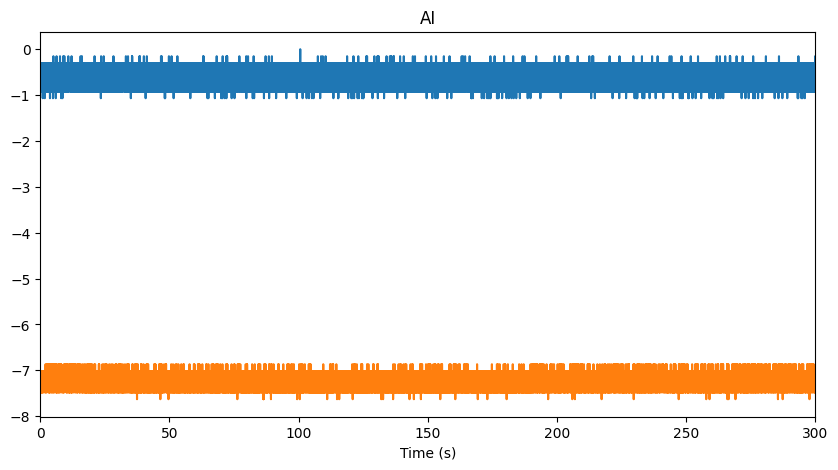

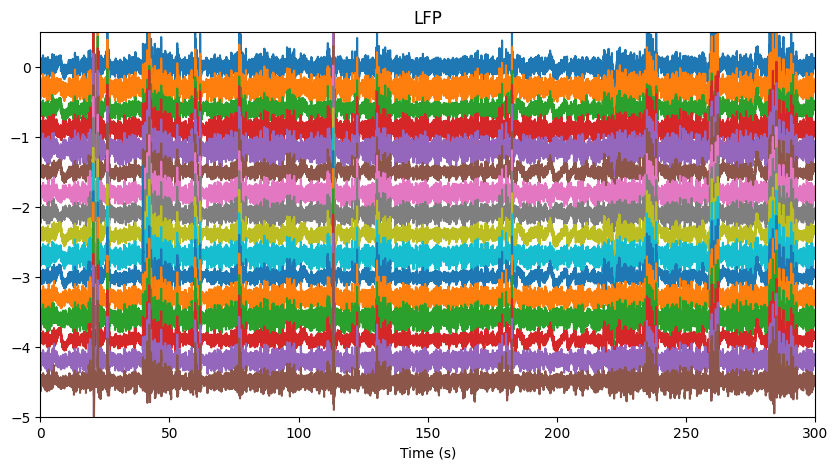

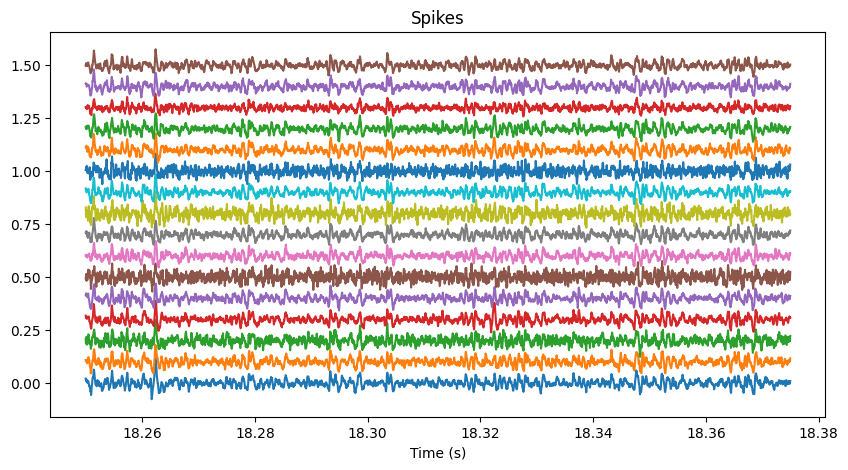

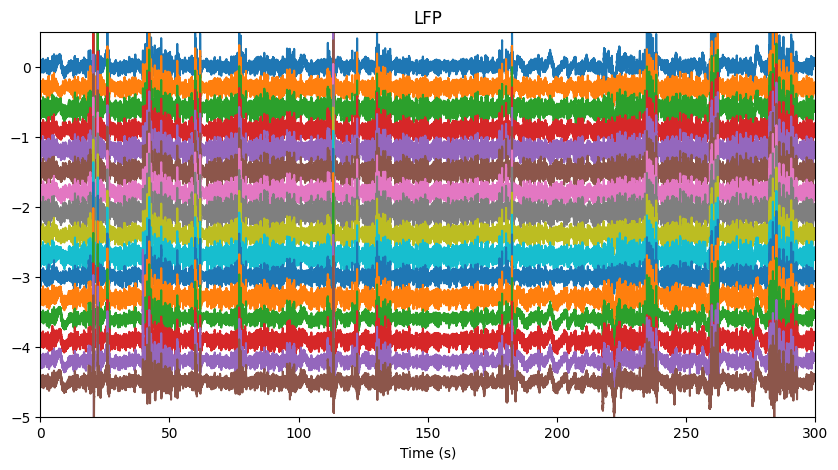

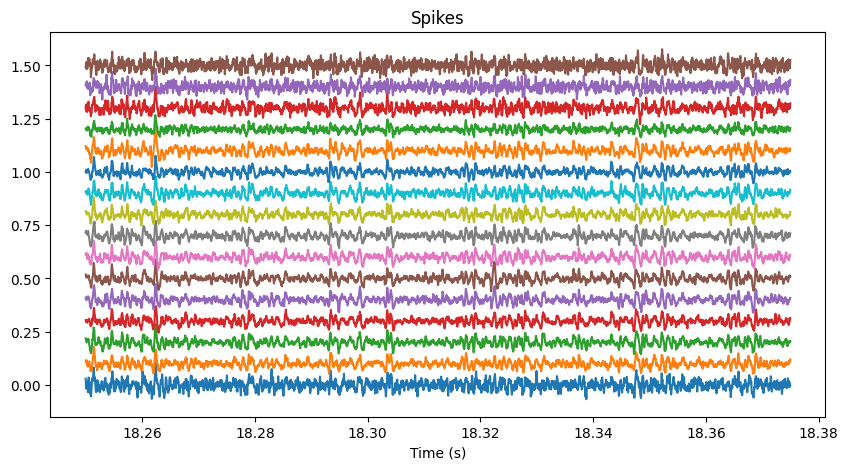

In [5]:
figsize = (10, 5)
tmax = 300

# plot AI
plt.figure(figsize=figsize)
for i, ai_channel in enumerate(ai.T):
    plt.plot(ai.times, ai_channel)
plt.title("AI")
plt.xlabel("Time (s)")
plt.xlim(0, tmax)
plt.show()

# before reorder
# plot LFP
plt.figure(figsize=figsize)
for i, lfp_channel in enumerate(lfp.T):
    plt.plot(lfp.times, lfp_channel - i * 0.3)
plt.title("LFP")
plt.xlabel("Time (s)")
plt.xlim(0, tmax)
plt.ylim(-5.0, 0.5)
plt.show()

# plot spikes
idx_start = 730000
idx_length = 5000

plt.figure(figsize=figsize)
for i, spikes_channel in enumerate(spikes.T):
    plt.plot(spikes.times[idx_start:idx_start+idx_length], spikes_channel[idx_start:idx_start+idx_length] + i * 0.1)
plt.title("Spikes")
plt.xlabel("Time (s)")
plt.show()

# after reorder
# reorder channel
# surface <- 8, 7, 9, 6, 12, 3, 11, 4, 14, 1, 15, 0, 13, 2, 10, 5 -> deep
lfp = lfp[:, [8, 7, 9, 6, 12, 3, 11, 4, 14, 1, 15, 0, 13, 2, 10, 5]]
spikes = spikes[:, [8, 7, 9, 6, 12, 3, 11, 4, 14, 1, 15, 0, 13, 2, 10, 5]]

# plot LFP
plt.figure(figsize=figsize)
for i, lfp_channel in enumerate(lfp.T):
    plt.plot(lfp.times, lfp_channel - i * 0.3)
plt.title("LFP")
plt.xlabel("Time (s)")
plt.xlim(0, tmax)
plt.ylim(-5.0, 0.5)
plt.show()

plt.figure(figsize=figsize)
for i, spikes_channel in enumerate(spikes.T):
    plt.plot(spikes.times[idx_start:idx_start+idx_length], spikes_channel[idx_start:idx_start+idx_length] + i * 0.1)
plt.title("Spikes")
plt.xlabel("Time (s)")
plt.show()

# Data Denosing

## noise filtering : band-pass filter

In [6]:
# サンプリングレートを取得
fs = int(lfp.sampling_rate)
nyquist = fs / 2

# バンドパスフィルタの設定
low_cutoff = 0.1  # 低域カットオフ周波数 (Hz)
high_cutoff = 100  # 高域カットオフ周波数 (Hz)

# ナイキスト周波数で正規化
low_normalized = low_cutoff / nyquist
high_normalized = high_cutoff / nyquist

# フィルタの次数を手動で設定
order = 4  # 4次のバターワースフィルタ

# バンドパスフィルタの設計
sos_bandpass = signal.butter(order, [low_normalized, high_normalized], btype='bandpass', output='sos')

# 60Hzノッチフィルタの設定
notch_freq = 60.0  # ノッチフィルタの中心周波数 (Hz)
quality_factor = 30.0  # Q値（高いほど狭い周波数帯域を除去）

# ノッチフィルタの設計（古いバージョン対応）
b_notch, a_notch = signal.iirnotch(notch_freq, quality_factor, fs)
sos_notch = signal.tf2sos(b_notch, a_notch)  # 伝達関数からSOSに変換

# 一括でフィルタリング：まずバンドパスフィルタを適用
lfp_filtered = signal.sosfiltfilt(sos_bandpass, lfp, axis=0)

# 次にノッチフィルタを適用
lfp_filtered = signal.sosfiltfilt(sos_notch, lfp_filtered, axis=0)

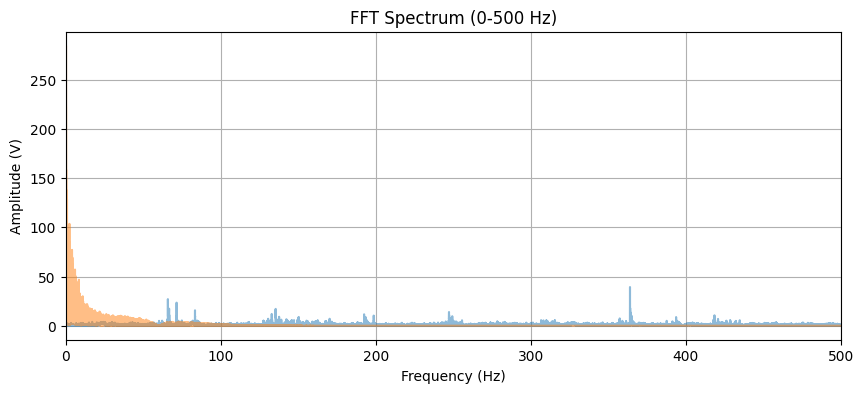

In [ ]:
# フーリエ変換
# FFT の計算
N = len(lfp)
fft_vals = fft(lfp[:, 0])
fft_freqs = fftfreq(N, 1/fs)  # 正しいサンプリング周波数を使用

# 正の周波数成分のみ抽出
pos_mask = fft_freqs >= 0
fft_vals = fft_vals[pos_mask]
fft_freqs = fft_freqs[pos_mask]

amplitudes = np.abs(fft_vals)
amplitudes /= np.mean(amplitudes)

# フーリエ変換
# FFT の計算
N = len(lfp_filtered)
fft_vals = fft(lfp_filtered[:, 0])
fft_freqs = fftfreq(N, 1/fs)  # 正しいサンプリング周波数を使用

# 正の周波数成分のみ抽出
pos_mask = fft_freqs >= 0
fft_vals = fft_vals[pos_mask]
fft_freqs = fft_freqs[pos_mask]

# 振幅の正規化
amplitudes_filtered = np.abs(fft_vals)
amplitudes_filtered /= np.mean(amplitudes_filtered)

# 周波数軸（Hz）を使用して0-500Hzまでをプロット
plt.figure(figsize=(10,4))
plt.plot(fft_freqs, amplitudes, alpha=0.5)
plt.plot(fft_freqs, amplitudes_filtered, alpha=0.5)
plt.title('FFT Spectrum (0-500 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V)')
plt.xlim(0, 500)  # 0から500Hzまでの範囲を表示
plt.grid(True)
plt.show()

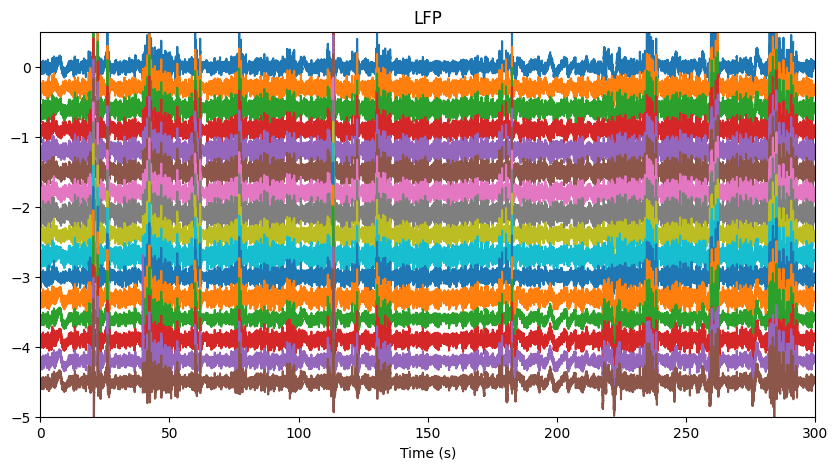

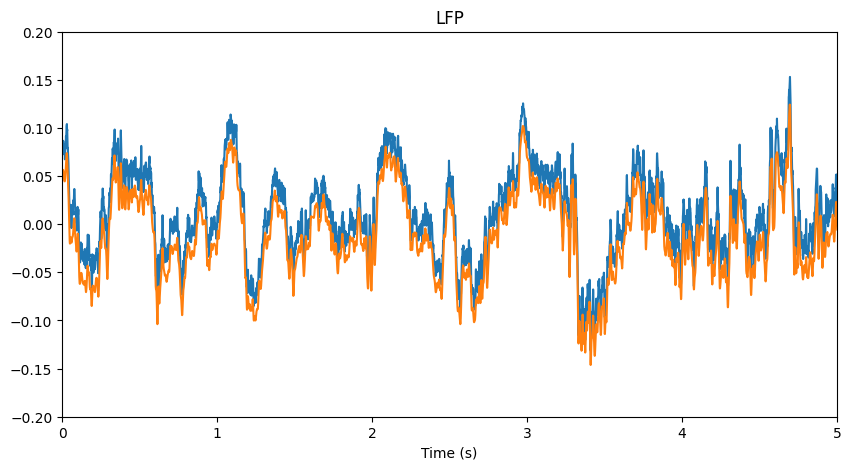

In [ ]:
# plot LFP
plt.figure(figsize=figsize)
for i, lfp_channel in enumerate(lfp_filtered.T):
    plt.plot(lfp.times, lfp_channel - i * 0.3)
plt.title("LFP")
plt.xlabel("Time (s)")
plt.xlim(0, tmax)
plt.ylim(-5.0, 0.5)
plt.show()

plt.figure(figsize=figsize)
plt.plot(lfp.times, lfp[:, 0])
plt.plot(lfp.times, lfp_filtered[:, 0])
plt.title("LFP")
plt.xlabel("Time (s)")
plt.xlim(0, 5)
plt.ylim(-0.2, 0.2)
plt.show()

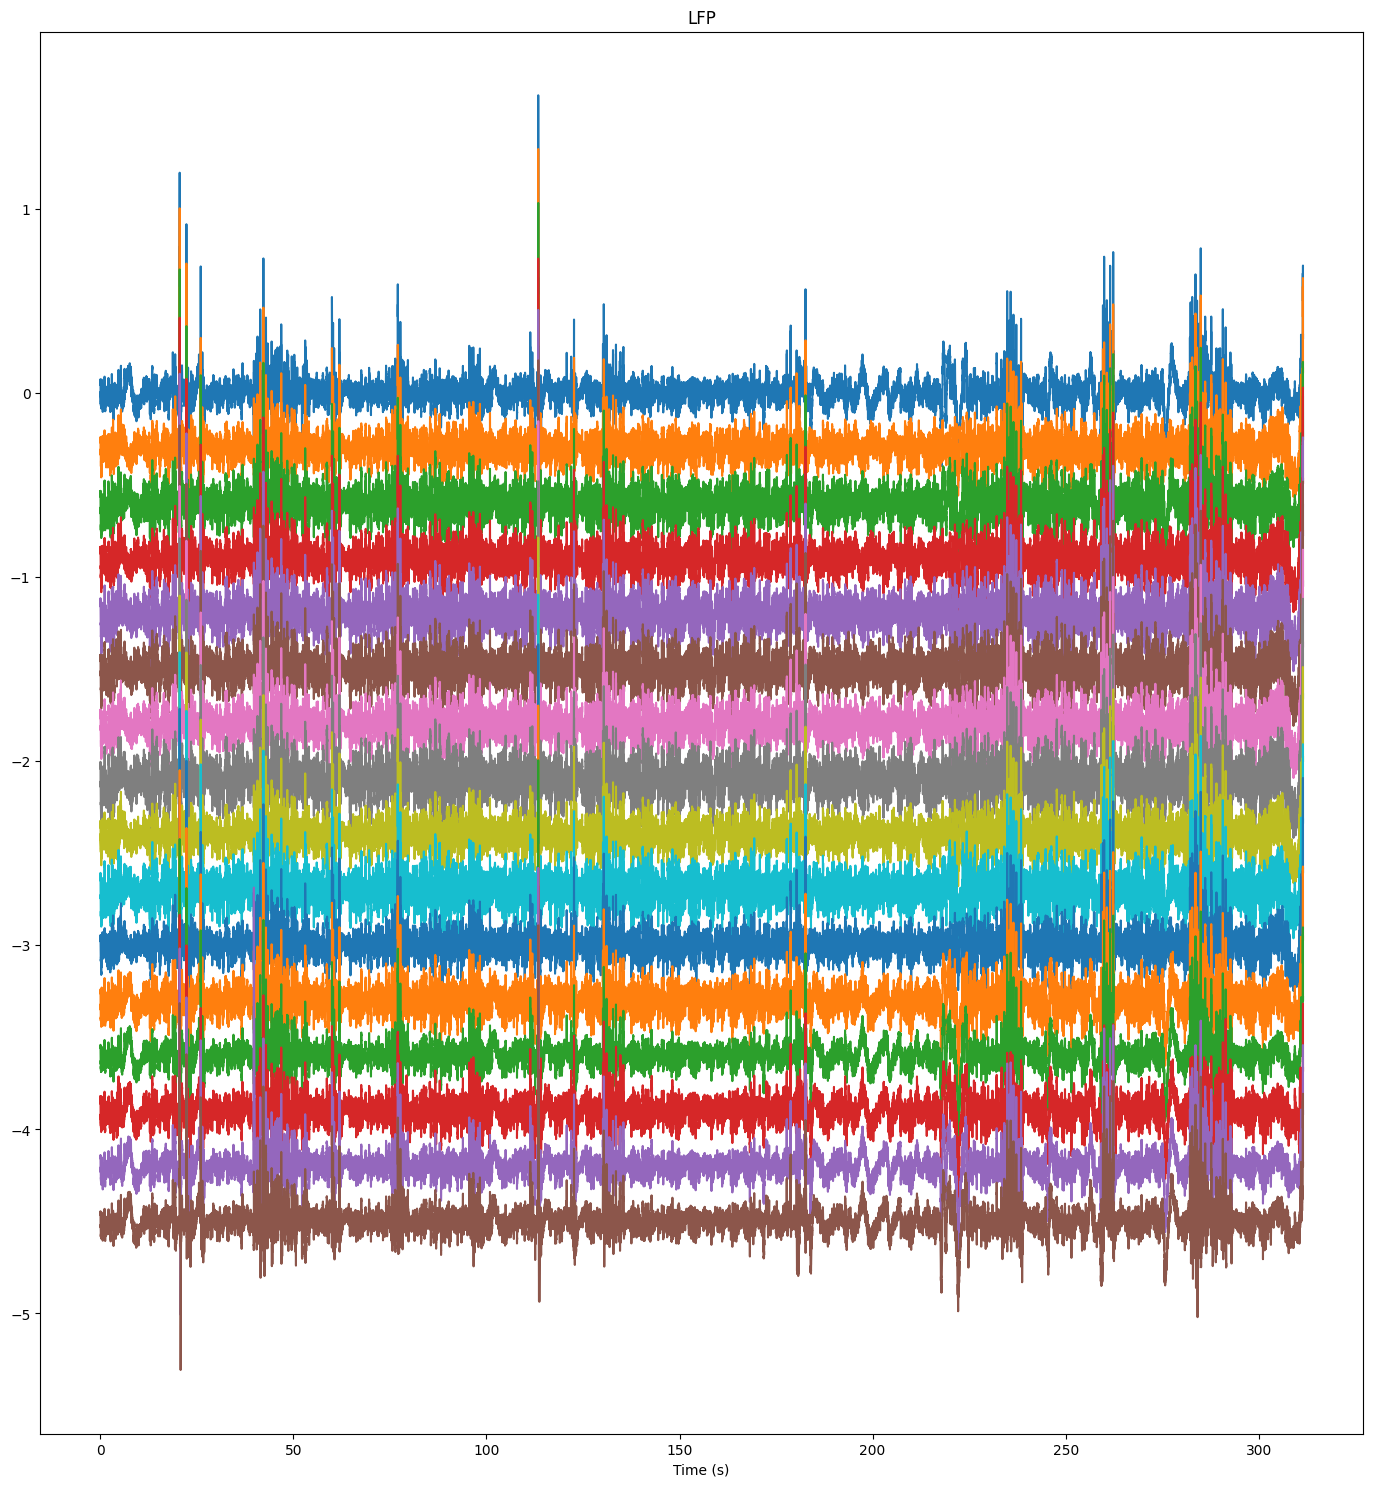

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk
import tkinter as tk

# メインウィンドウ作成
root = tk.Tk()
root.title("LFP Viewer")
root.geometry("1200x800")

# 図の作成
fig, ax = plt.subplots(figsize=(10, 6))

# 各チャンネルをプロット
for i, lfp_channel in enumerate(lfp_filtered.T):
    ax.plot(lfp.times, lfp_channel - i * 0.3)

# プロット設定
ax.set_title("LFP")
ax.set_xlabel("Time (s)")

# キャンバスをTkウィンドウに埋め込み
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.draw()
canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=1)

# ナビゲーションツールバーを追加
toolbar = NavigationToolbar2Tk(canvas, root)
toolbar.update()
canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=1)

# Tkインターフェースを実行
tk.mainloop()

## noise filtering : substract

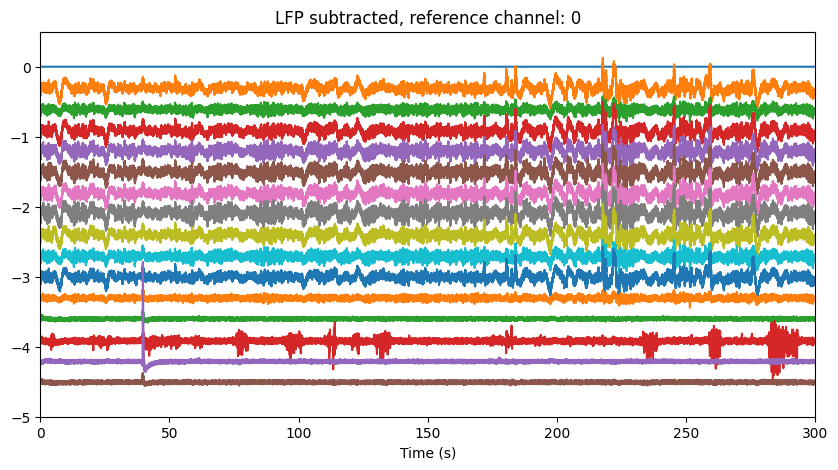

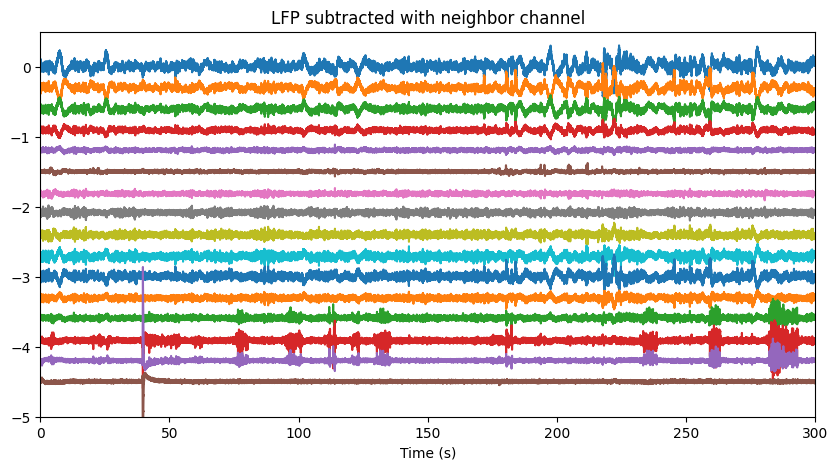

In [ ]:
# substract with reference channel
channel_ref = 0

lfp_subtracted = lfp.copy()
lfp_subtracted = lfp_subtracted - lfp_subtracted[:, channel_ref]

# plot LFP
plt.figure(figsize=figsize)
for i, lfp_channel in enumerate(lfp_subtracted.T):
    plt.plot(lfp.times, lfp_channel - i * 0.3)
plt.title(f"LFP subtracted, reference channel: {channel_ref}")
plt.xlabel("Time (s)")
plt.xlim(0, tmax)
plt.ylim(-5.0, 0.5)
plt.show()

# substract with neighbor channel
# 0    : - (channel 1)
# 1~14 : - (channel i-1)/2 - (channel i+1)/2
# 15   : - (channel 14)
lfp_subtracted = lfp.copy()
for i, lfp_channel in enumerate(lfp_subtracted.T):
    if i == 0:
        lfp_subtracted[:, 0] -= lfp[:, 1]
    elif i == len(lfp_subtracted.T) - 1:
        lfp_subtracted[:, -1] -= lfp[:, -2]
    else:
        lfp_subtracted[:, i] -= ((lfp[:, i-1] + lfp[:, i+1])/2)

# plot LFP
plt.figure(figsize=figsize)
for i, lfp_channel in enumerate(lfp_subtracted.T):
    plt.plot(lfp.times, lfp_channel - i * 0.3)
plt.title(f"LFP subtracted with neighbor channel")
plt.xlabel("Time (s)")
plt.xlim(0, tmax)
plt.ylim(-5.0, 0.5)
plt.show()

## noise filtering : ICA

In [34]:
import sys
import numpy as np
from PyQt5.QtCore import Qt, pyqtSignal
from PyQt5.QtWidgets import QApplication, QMainWindow, QVBoxLayout, QWidget
from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg
from matplotlib.figure import Figure
import matplotlib.patches as patches
from matplotlib.backend_bases import MouseButton

class MplCanvas(FigureCanvasQTAgg):
    def __init__(self, parent=None, width=12, height=8, dpi=100):
        fig = Figure(figsize=(width, height), dpi=dpi)
        self.axes = fig.add_subplot(111)
        super(MplCanvas, self).__init__(fig)

class NoiseCurator(QMainWindow):
    finished = pyqtSignal(object)  # 終了時に結果を返すシグナル
    
    def __init__(self, lfp, lfp_filtered):
        super().__init__()
        
        # データ保存
        self.lfp = lfp
        self.lfp_filtered = lfp_filtered
        self.times = lfp.times
        
        # ノイズマスク配列の初期化
        self.noise_mask = np.zeros(len(self.times), dtype=bool)
        self.temp_mask = np.zeros(len(self.times), dtype=bool)
        
        # 描画パラメータ
        self.y_min = np.min(lfp_filtered) - len(lfp_filtered.T) * 0.3
        self.y_max = np.max(lfp_filtered)
        self.x_min = 0
        self.x_max = np.max(self.times)
        
        # ドラッグ用変数
        self.drag_start_x = None
        self.dragging = False
        self.drag_button = None
        self.panning = False
        self.pan_start_x = None
        
        # UI設定
        self.setWindowTitle("Noise Curator")
        self.setGeometry(100, 100, 1200, 800)
        
        # キャンバス作成
        self.canvas = MplCanvas(self, width=12, height=8, dpi=100)
        
        # レイアウト設定
        layout = QVBoxLayout()
        layout.addWidget(self.canvas)
        
        # ウィジェット設定
        widget = QWidget()
        widget.setLayout(layout)
        self.setCentralWidget(widget)
        
        # プロット初期化
        self.init_plot()
        
        # イベント接続
        self.canvas.mpl_connect('button_press_event', self.on_press)
        self.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.canvas.mpl_connect('button_release_event', self.on_release)
        self.canvas.mpl_connect('scroll_event', self.on_scroll)
        
    def init_plot(self):
        # プロット初期化
        self.canvas.axes.clear()
        
        # 各チャンネルをプロット
        for i, lfp_channel in enumerate(self.lfp_filtered.T):
            self.canvas.axes.plot(self.times, lfp_channel - i * 0.3)
        
        # プロット設定
        self.canvas.axes.set_title("Noise Curator\nLeft Drag: mark noise, Right Drag: unmark noise, Middle Drag: pan, Scroll: zoom, Esc: close")
        self.canvas.axes.set_xlabel("Time (s)")
        self.canvas.axes.set_xlim(self.x_min, self.x_max)
        self.canvas.axes.set_ylim(self.y_min, self.y_max)
        
        # ノイズ領域の表示
        self.update_display()
        
        self.canvas.draw()
    
    def update_display(self):
        # 既存のパッチをクリア
        for patch in self.canvas.axes.patches:
            patch.remove()
        
        # 現在のマスクと一時マスクを組み合わせる
        display_mask = self.noise_mask.copy()
        if self.dragging:
            if self.drag_button == MouseButton.LEFT:
                display_mask = display_mask | self.temp_mask
            elif self.drag_button == MouseButton.RIGHT:
                display_mask = display_mask & ~self.temp_mask
        
        # Trueの連続領域を特定して四角形で描画
        in_region = False
        start_idx = 0
        
        for i in range(len(display_mask)):
            if display_mask[i] and not in_region:
                in_region = True
                start_idx = i
            elif not display_mask[i] and in_region:
                in_region = False
                # 連続領域を四角形で描画
                rect = patches.Rectangle(
                    (self.times[start_idx], self.y_min),
                    self.times[i-1] - self.times[start_idx],
                    self.y_max - self.y_min,
                    linewidth=1,
                    edgecolor='none',
                    facecolor='purple',
                    alpha=0.3
                )
                self.canvas.axes.add_patch(rect)
        
        # 最後の領域が続いている場合
        if in_region:
            rect = patches.Rectangle(
                (self.times[start_idx], self.y_min),
                self.times[-1] - self.times[start_idx],
                self.y_max - self.y_min,
                linewidth=1,
                edgecolor='none',
                facecolor='purple',
                alpha=0.3
            )
            self.canvas.axes.add_patch(rect)
        
        self.canvas.draw_idle()
    
    def on_press(self, event):
        # プロット領域外の場合は何もしない
        if event.inaxes != self.canvas.axes:
            return
        
        # ボタンに応じた処理
        if event.button == MouseButton.LEFT:  # 左ボタン：マーキング
            self.drag_start_x = event.xdata
            self.dragging = True
            self.drag_button = MouseButton.LEFT
            self.temp_mask = np.zeros(len(self.times), dtype=bool)
            
        elif event.button == MouseButton.RIGHT:  # 右ボタン：マーク解除
            self.drag_start_x = event.xdata
            self.dragging = True
            self.drag_button = MouseButton.RIGHT
            self.temp_mask = np.zeros(len(self.times), dtype=bool)
            
        elif event.button == MouseButton.MIDDLE:  # 中ボタン：パン
            self.panning = True
            self.pan_start_x = event.xdata
    
    def on_motion(self, event):
        # プロット領域外の場合も処理できるようにする
        if event.inaxes != self.canvas.axes:
            return
        
        # マーキングドラッグ中
        if self.dragging:
            # 一時マスクをリセット
            self.temp_mask = np.zeros(len(self.times), dtype=bool)
            
            # x座標を範囲内に制限
            current_x = min(max(event.xdata, self.x_min), self.x_max)
            
            # 範囲内のドラッグのみ処理
            x_start = min(self.drag_start_x, current_x)
            x_end = max(self.drag_start_x, current_x)
            
            # 時間配列のインデックスに変換
            start_idx = np.searchsorted(self.times, x_start)
            end_idx = np.searchsorted(self.times, x_end)
            
            # 範囲が有効な場合のみ処理
            if start_idx < end_idx:
                # 一時マスクを更新
                self.temp_mask[start_idx:end_idx] = True
                
                # 表示を更新
                self.update_display()
        
        # パンニング中
        elif self.panning:
            # 現在の表示範囲を取得
            xlim = self.canvas.axes.get_xlim()
            
            # 動いた距離を計算
            dx = event.xdata - self.pan_start_x
            
            # 新しい範囲を計算
            new_left = xlim[0] - dx
            new_right = xlim[1] - dx
            
            # 表示範囲がデータ範囲内に収まるように制限
            if new_left < self.x_min:
                new_right += (self.x_min - new_left)
                new_left = self.x_min
            elif new_right > self.x_max:
                new_left -= (new_right - self.x_max)
                new_right = self.x_max
                
            # 新しい表示範囲を設定
            self.canvas.axes.set_xlim(new_left, new_right)
            self.canvas.draw_idle()
            
            # パンの開始位置を更新
            self.pan_start_x = event.xdata
    
    def on_release(self, event):
        # マーキングドラッグ中
        if self.dragging:
            if event.inaxes == self.canvas.axes:
                # x座標を範囲内に制限
                current_x = min(max(event.xdata, self.x_min), self.x_max)
                
                # 開始位置と終了位置を整理
                x_start = min(self.drag_start_x, current_x)
                x_end = max(self.drag_start_x, current_x)
                
                # 時間配列のインデックスに変換
                start_idx = np.searchsorted(self.times, x_start)
                end_idx = np.searchsorted(self.times, x_end)
                
                # 範囲が有効な場合のみ処理
                if start_idx < end_idx:
                    # 左クリックの場合はTrue、右クリックの場合はFalseに設定
                    if self.drag_button == MouseButton.LEFT:
                        self.noise_mask[start_idx:end_idx] = True
                    elif self.drag_button == MouseButton.RIGHT:
                        self.noise_mask[start_idx:end_idx] = False
            
            # ドラッグ状態をリセット
            self.dragging = False
            self.temp_mask = np.zeros(len(self.times), dtype=bool)
            
            # 表示を更新
            self.update_display()
        
        # パンニング終了
        elif self.panning:
            self.panning = False
        
        self.drag_start_x = None
        self.pan_start_x = None
        
    def on_scroll(self, event):
        # スクロールによるx方向のズーム
        if event.inaxes == self.canvas.axes:
            # 現在の表示範囲
            cur_xlim = self.canvas.axes.get_xlim()
            cur_xrange = cur_xlim[1] - cur_xlim[0]
            
            # ズームの中心
            center = event.xdata
            
            # ズーム倍率
            scale_factor = 0.66 if event.button == 'up' else 1.5
            
            # 新しい範囲の幅を計算
            new_width = cur_xrange * scale_factor
            
            # 新しい端点を計算
            left = center - new_width/2
            right = center + new_width/2
            
            # 範囲調整（データ範囲内に収める）
            # 全ての値を数値として扱う
            x_min = float(self.x_min) if hasattr(self.x_min, '__float__') else 0
            x_max = float(self.x_max) if hasattr(self.x_max, '__float__') else len(self.times)
            
            if left < x_min:
                left = x_min
            if right > x_max:
                right = x_max
            
            # 最小表示幅を確保
            min_width = (x_max - x_min) * 0.01  # 全範囲の1%
            if right - left < min_width:
                # 中心を維持しながら最小幅を確保
                center = (left + right) / 2
                left = center - min_width/2
                right = center + min_width/2
            
            # 表示更新
            self.canvas.axes.set_xlim(left, right)
            self.canvas.draw_idle()
    
    def keyPressEvent(self, event):
        # ネイティブQtのキーイベント処理
        if event.key() == Qt.Key_Escape:
            self.finish()
    
    def closeEvent(self, event):
        # ウィンドウが閉じられたときの処理
        self.finish()
        event.accept()
    
    def finish(self):
        # 結果を送信して終了
        self.finished.emit(self.noise_mask)
        self.close()
    
    def get_noise_mask(self):
        return self.noise_mask

def create_noise_curator(lfp, lfp_filtered):
    app = QApplication.instance()
    if app is None:
        app = QApplication(sys.argv)
    
    main_window = NoiseCurator(lfp, lfp_filtered)
    
    # 結果を格納する変数
    result = [None]
    
    # 終了シグナルのハンドラ
    def on_finished(mask):
        result[0] = mask
        app.quit()
    
    # シグナルに接続
    main_window.finished.connect(on_finished)
    main_window.show()
    
    # イベントループを実行
    app.exec_()
    
    # 結果を返す
    return result[0]

# 使用例
noise_mask = create_noise_curator(lfp, lfp_filtered)

100973


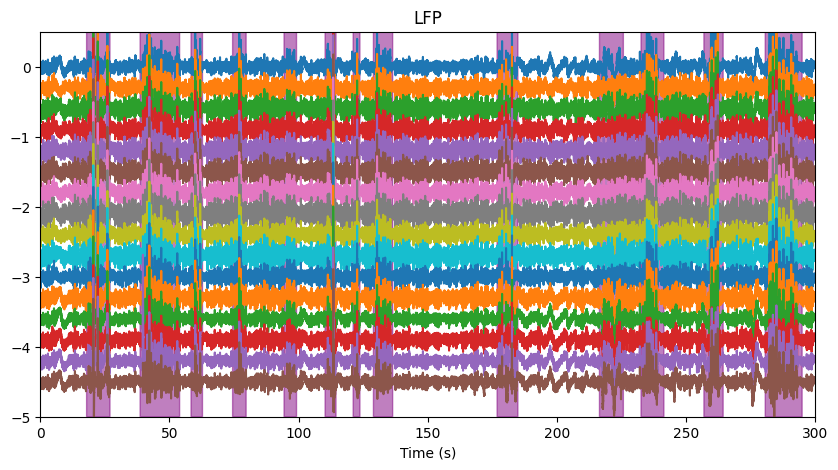

In [35]:
print(np.sum(noise_mask))

ymin, ymax = -5.0, 0.5

plt.figure(figsize=figsize)
for i, lfp_channel in enumerate(lfp_filtered.T):
    plt.plot(lfp.times, lfp_channel - i * 0.3)

y1 = np.ones(len(lfp.times)) * ymin
y2 = np.ones(len(lfp.times)) * ymax

y1[~noise_mask] = np.nan
y2[~noise_mask] = np.nan

plt.fill_between(lfp.times, y1=y1, y2=y2, color="purple", alpha=0.5)
plt.title("LFP")
plt.xlabel("Time (s)")
plt.xlim(0, tmax)
plt.ylim(ymin, ymax)
plt.show()

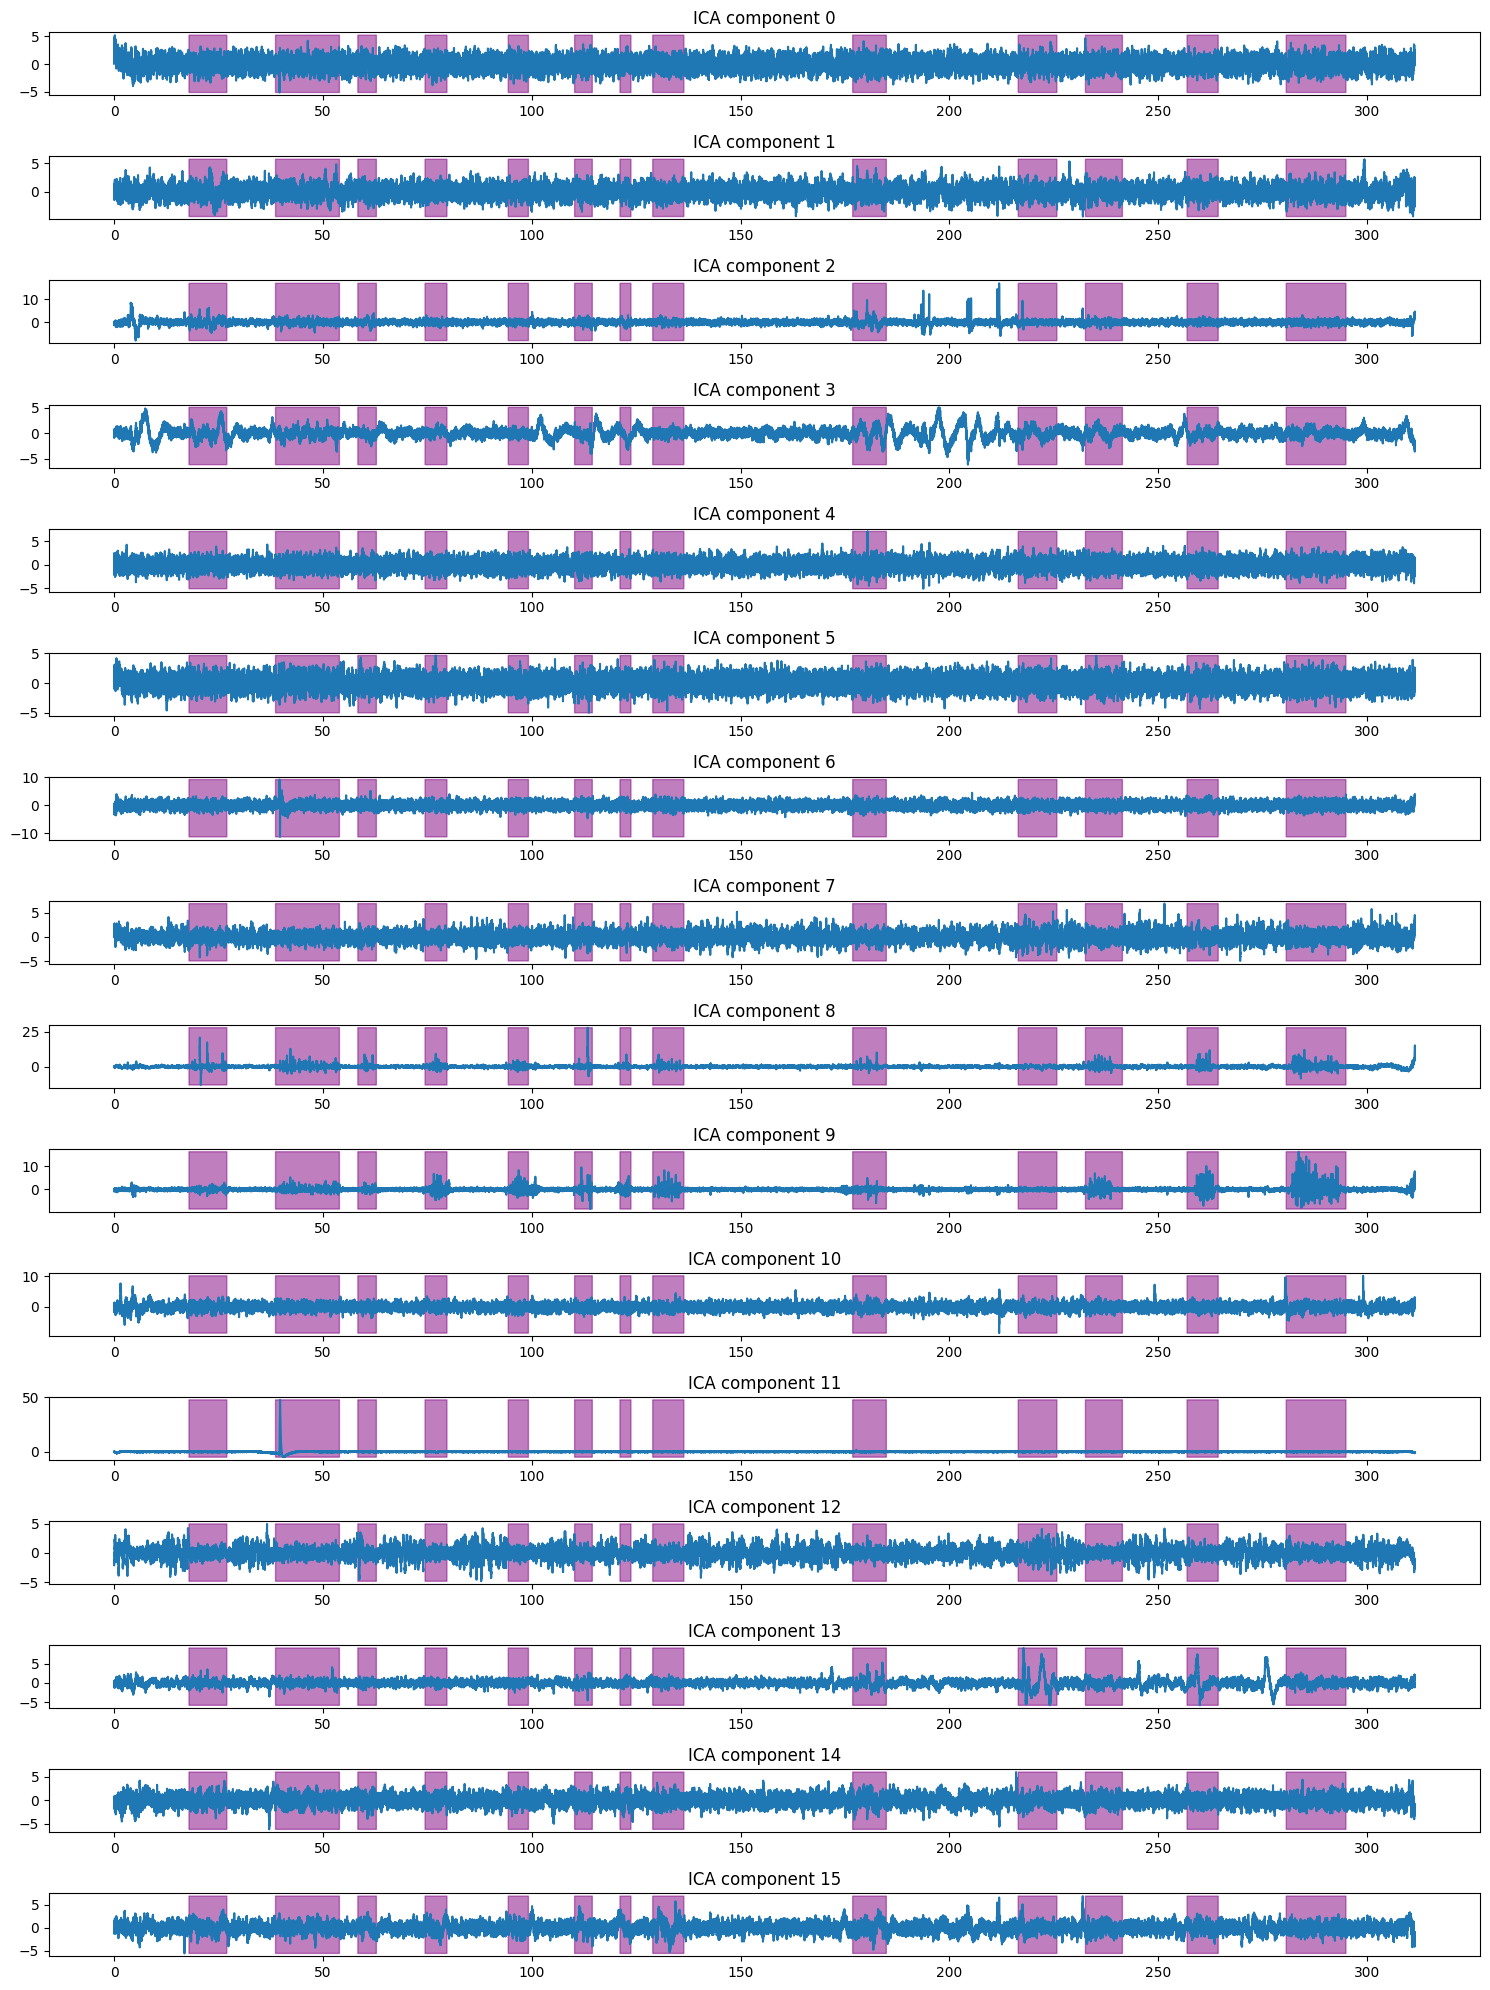

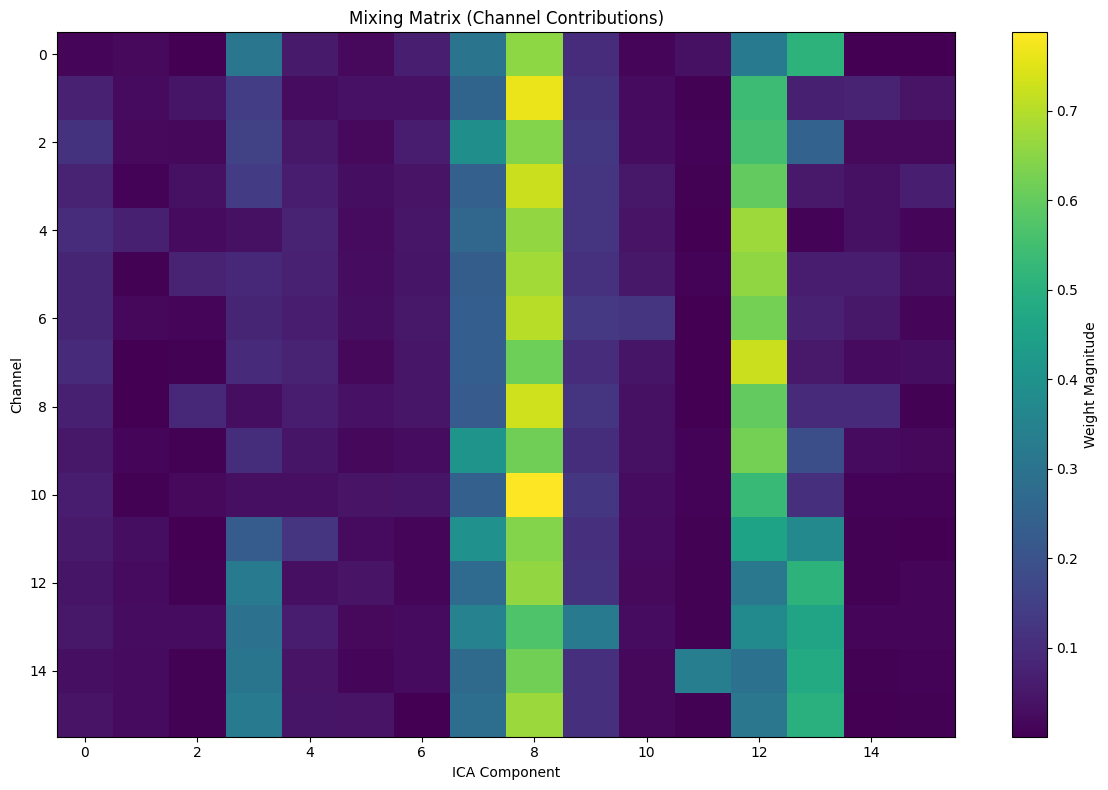

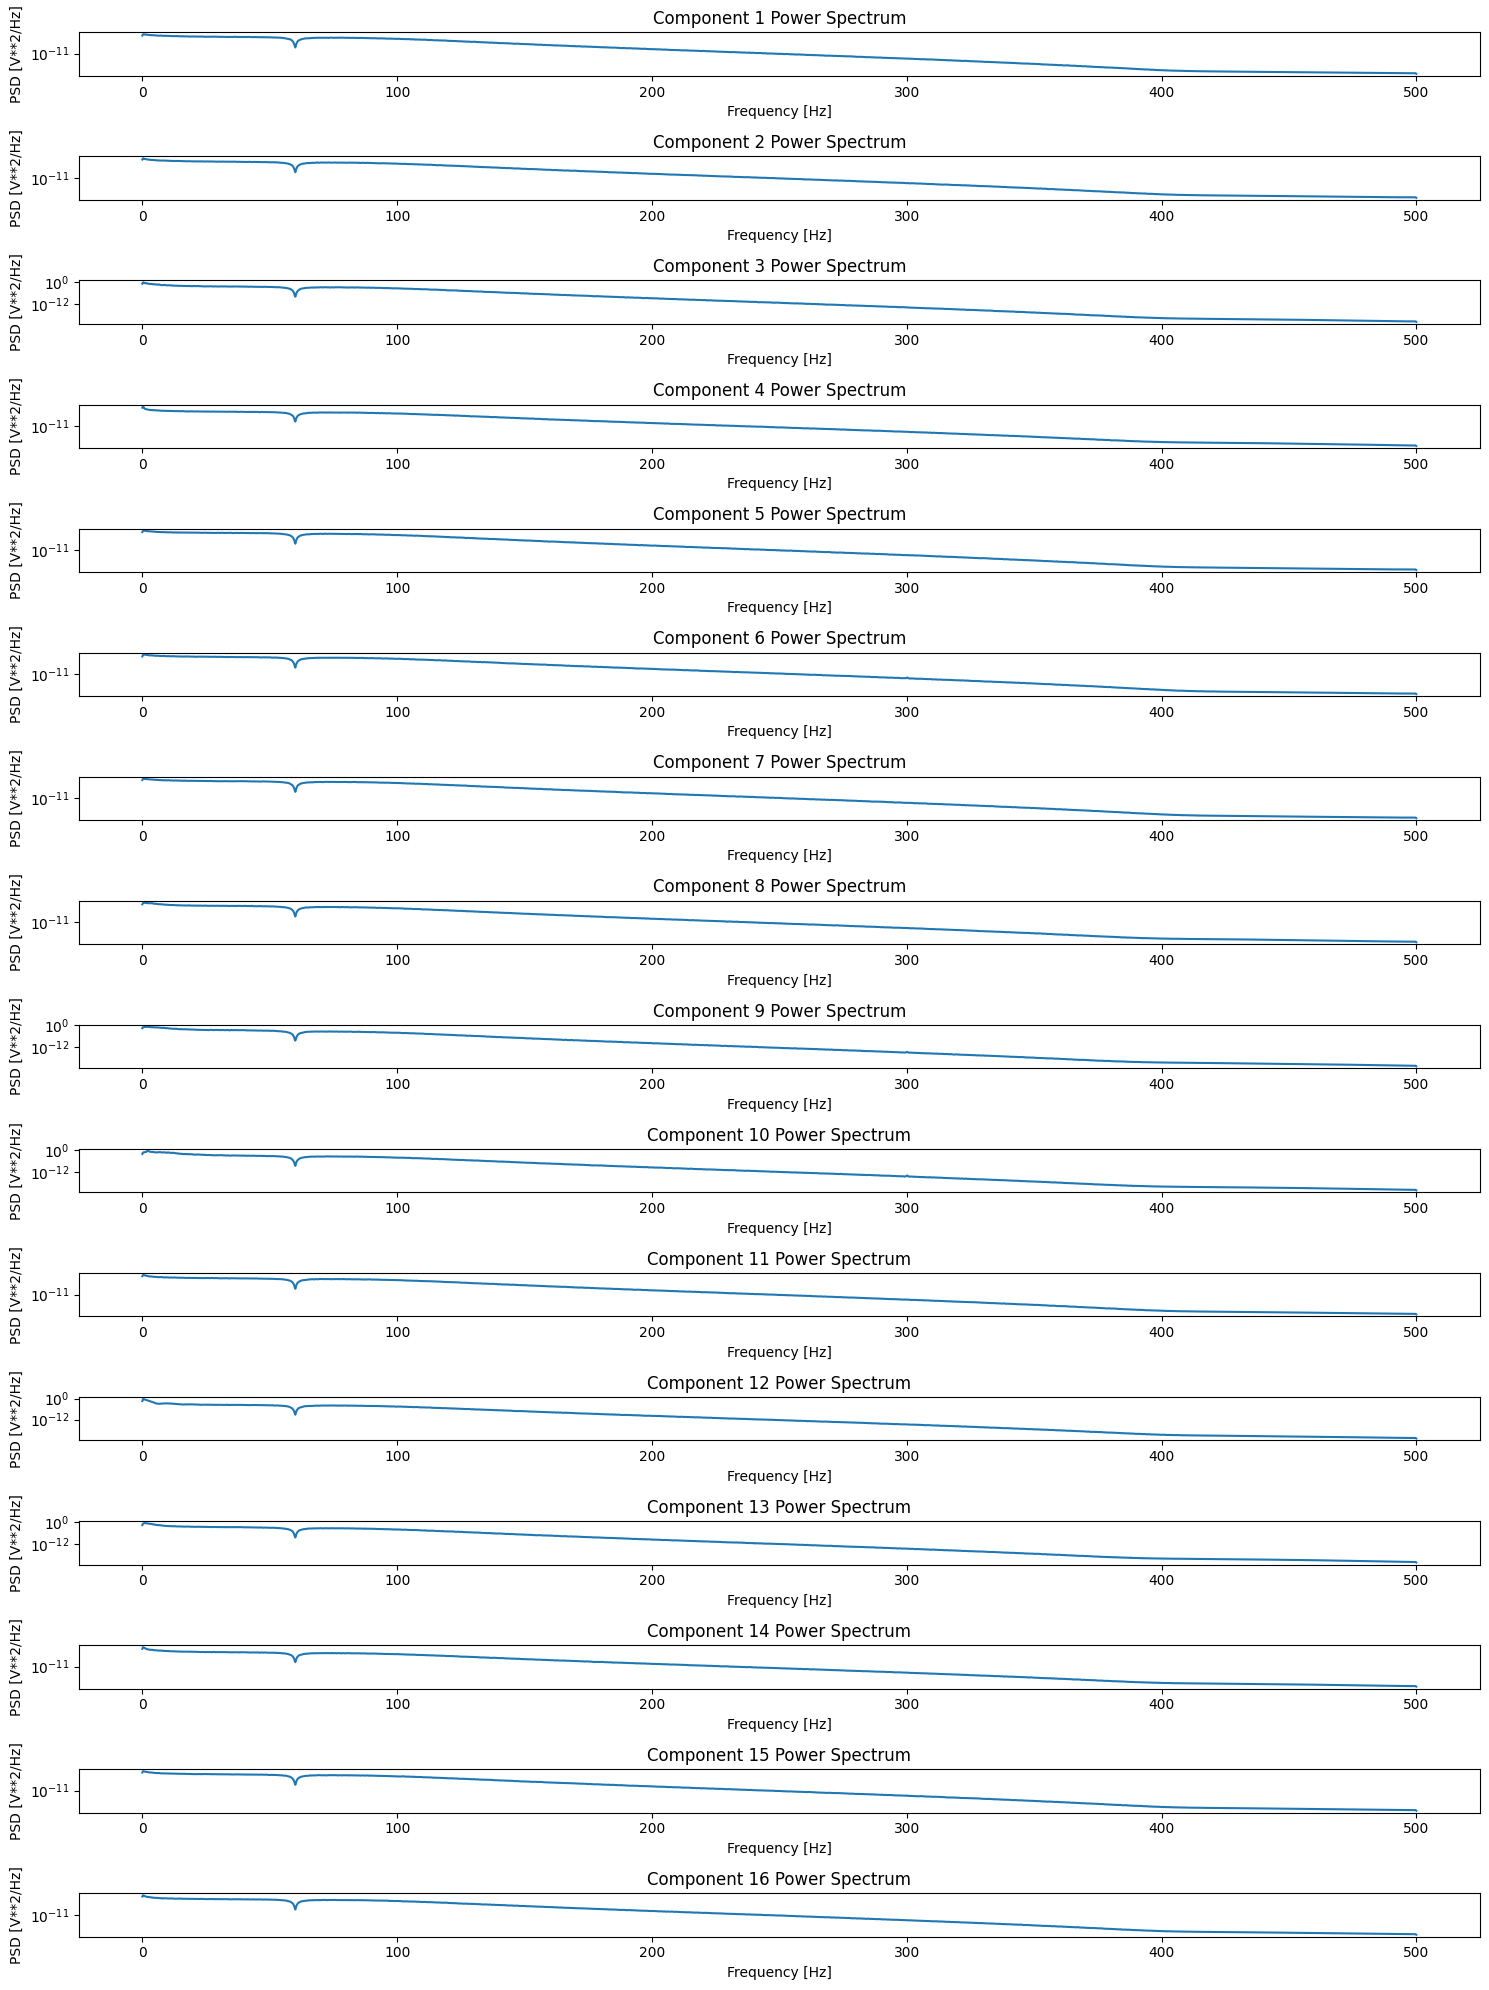

In [39]:
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
from scipy import signal

# データの前処理
# 各チャンネルの平均を0に、分散を1に正規化するとICAの性能が向上する場合が多い
X = lfp_filtered.copy()
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# FastICAの適用
n_components = 16  # 抽出する独立成分の数（通常はチャンネル数と同じ）
ica = FastICA(n_components=n_components, random_state=42, max_iter=2000, tol=0.0001)
S = ica.fit_transform(X)  # 独立成分
A = ica.mixing_  # 混合行列

# 各ICA成分の時間的特性を可視化
plt.figure(figsize=(15, 20))
for i in range(n_components):
    plt.subplot(n_components, 1, i+1)
    plt.plot(lfp.times, S[:, i])
    plt.title(f"ICA component {i}")
    y1 = np.ones(len(S)) * np.min(S[:, i])
    y2 = np.ones(len(S)) * np.max(S[:, i])
    y1[~noise_mask] = np.nan
    y2[~noise_mask] = np.nan
    plt.fill_between(lfp.times, y1=y1, y2=y2, color="purple", alpha=0.5)
plt.tight_layout()
plt.show()

# 各成分の空間的寄与（混合行列）を可視化
plt.figure(figsize=(12, 8))
plt.imshow(np.abs(A), aspect='auto', interpolation='nearest')
plt.colorbar(label='Weight Magnitude')
plt.xlabel('ICA Component')
plt.ylabel('Channel')
plt.title('Mixing Matrix (Channel Contributions)')
plt.tight_layout()
plt.show()

# スペクトル分析でノイズ成分を識別
fs = int(lfp.sampling_rate)  # サンプリングレート

plt.figure(figsize=(15, 20))
for i in range(n_components):
    f, Pxx = signal.welch(S[:, i], fs=fs, nperseg=4096)
    plt.subplot(n_components, 1, i+1)
    plt.semilogy(f, Pxx)
    plt.title(f"Component {i+1} Power Spectrum")
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')
plt.tight_layout()
plt.show()

# ノイズ成分の特定（手動で行う）
# 以下の特徴を持つ成分を注意深く検討
# - 高周波ノイズ: スペクトルで高周波帯域にパワーが集中
# - 電源ノイズ: 60Hz付近に鋭いピーク
# - 機械的ノイズ: 不自然な鋭いスパイク
# - 生物学的アーティファクト: 特徴的なリズムや波形パターン
noise_components = [8, 9]  # 例: [0, 2, 5] など、除去したい成分のインデックス

# ノイズ成分を0に設定して信号を再構成
S_cleaned = S.copy()
for idx in noise_components:
    S_cleaned[:, idx] = 0

# クリーンな信号に変換
X_cleaned = np.dot(S_cleaned, A.T)

# 元のスケールに戻す
X_cleaned = X_cleaned * np.std(lfp_filtered, axis=0) + np.mean(lfp_filtered, axis=0)

# 結果の保存
lfp_ica = X_cleaned

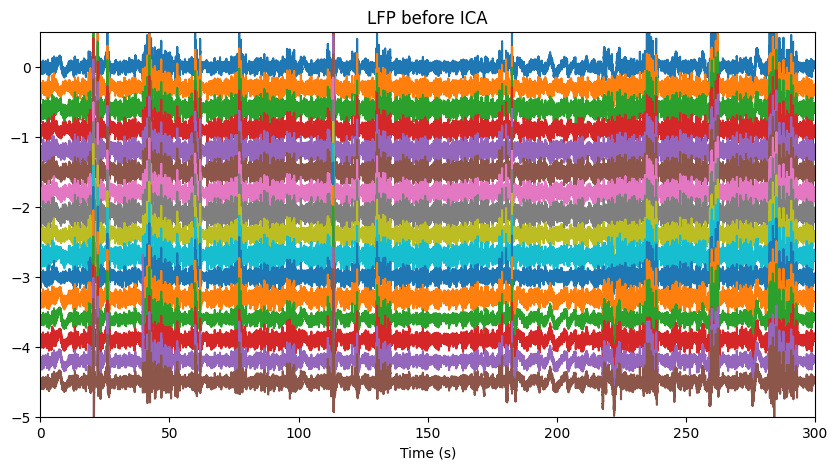

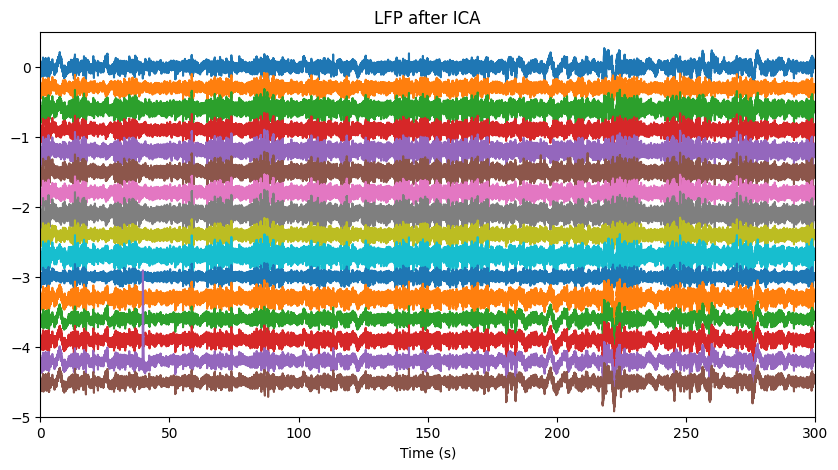

In [41]:
ymin, ymax = -5.0, 0.5

plt.figure(figsize=figsize)
for i, lfp_channel in enumerate(lfp_filtered.T):
    plt.plot(lfp.times, lfp_channel - i * 0.3)

plt.title("LFP before ICA")
plt.xlabel("Time (s)")
plt.xlim(0, tmax)
plt.ylim(ymin, ymax)
plt.show()

plt.figure(figsize=figsize)
for i, lfp_channel in enumerate(lfp_ica.T):
    plt.plot(lfp.times, lfp_channel - i * 0.3)

plt.title("LFP after ICA")
plt.xlabel("Time (s)")
plt.xlim(0, tmax)
plt.ylim(ymin, ymax)
plt.show()

In [42]:
# define final denoised data
lfp_denoised = lfp_ica

# Wavelet transform

In [ ]:
fs = int(lfp.sampling_rate)
wavelet = "cmor1.5-1.0"

# 解析したい周波数帯
frequencies = np.arange(1, 61, 1)  # 1Hzから60Hzまで1Hz刻み
# 各周波数に対応するスケール値を計算　周波数をそのままは使えない！！！！
scales = pywt.frequency2scale(wavelet, frequencies) * fs
cwtmatr, freq = pywt.cwt(lfp_denoised.T, scales, wavelet, sampling_period=1/fs)
cwtmatr = np.abs(cwtmatr)

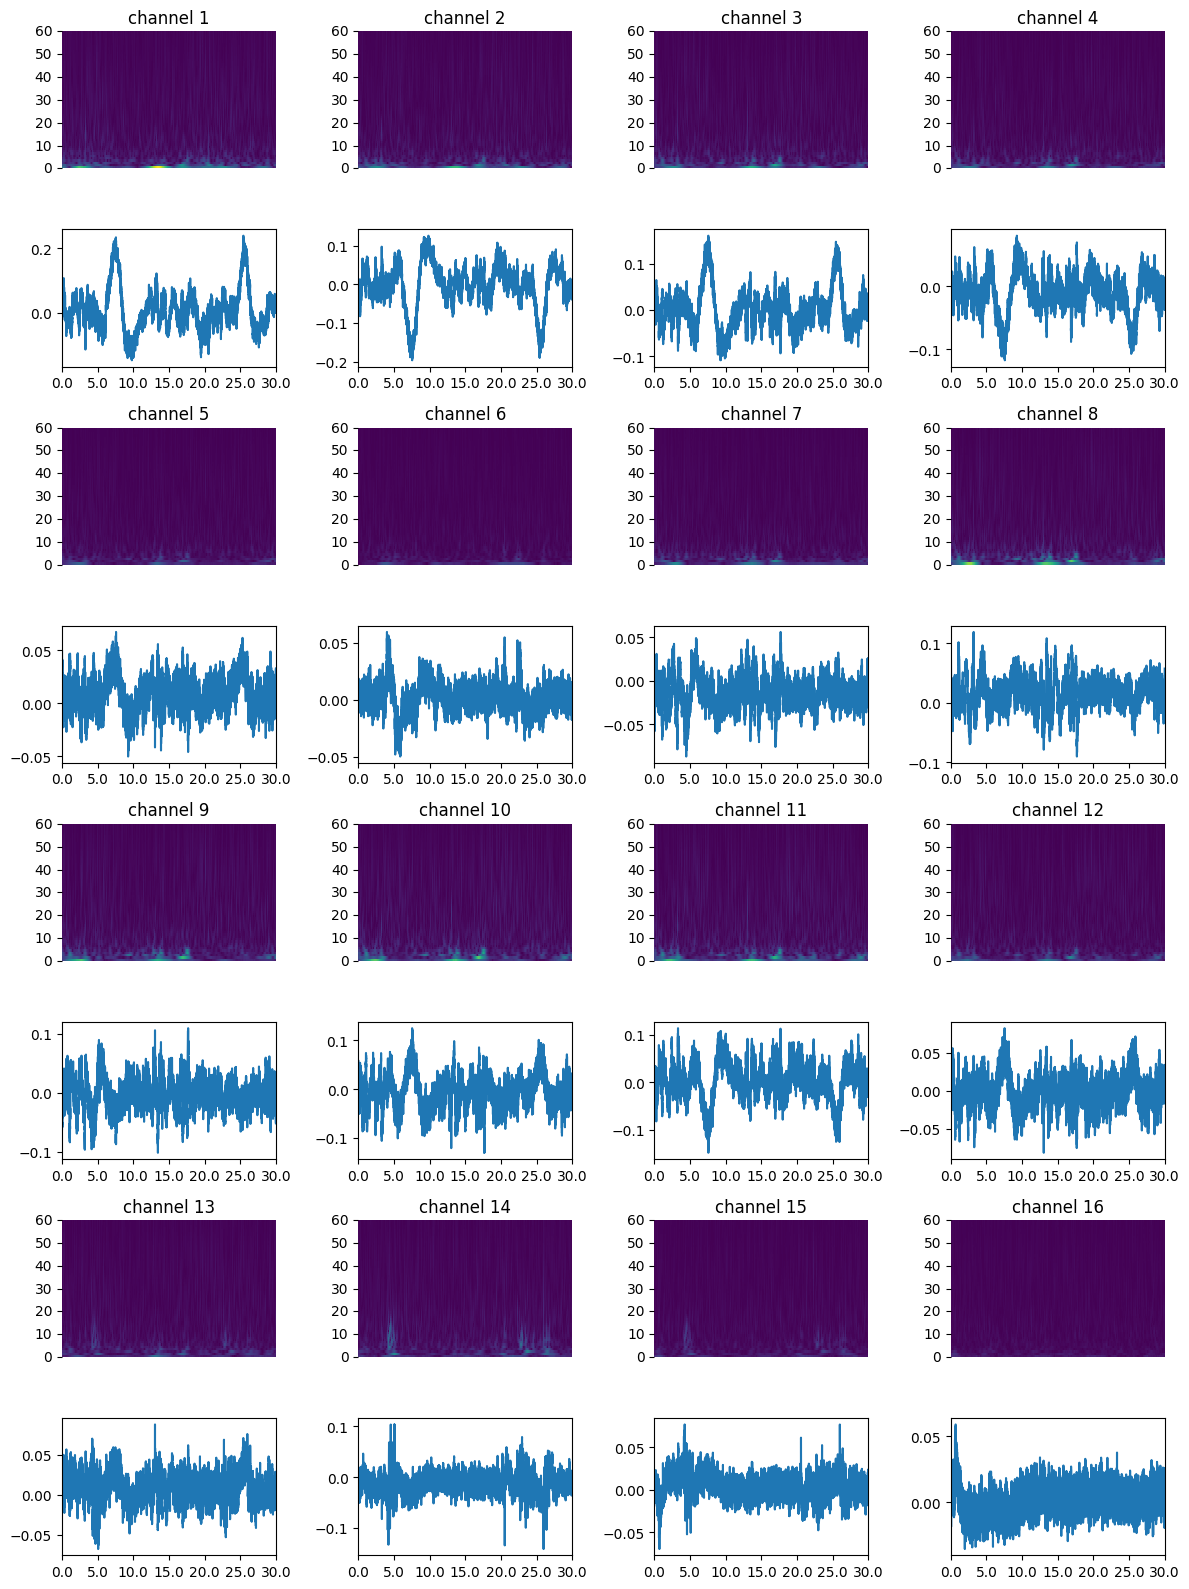

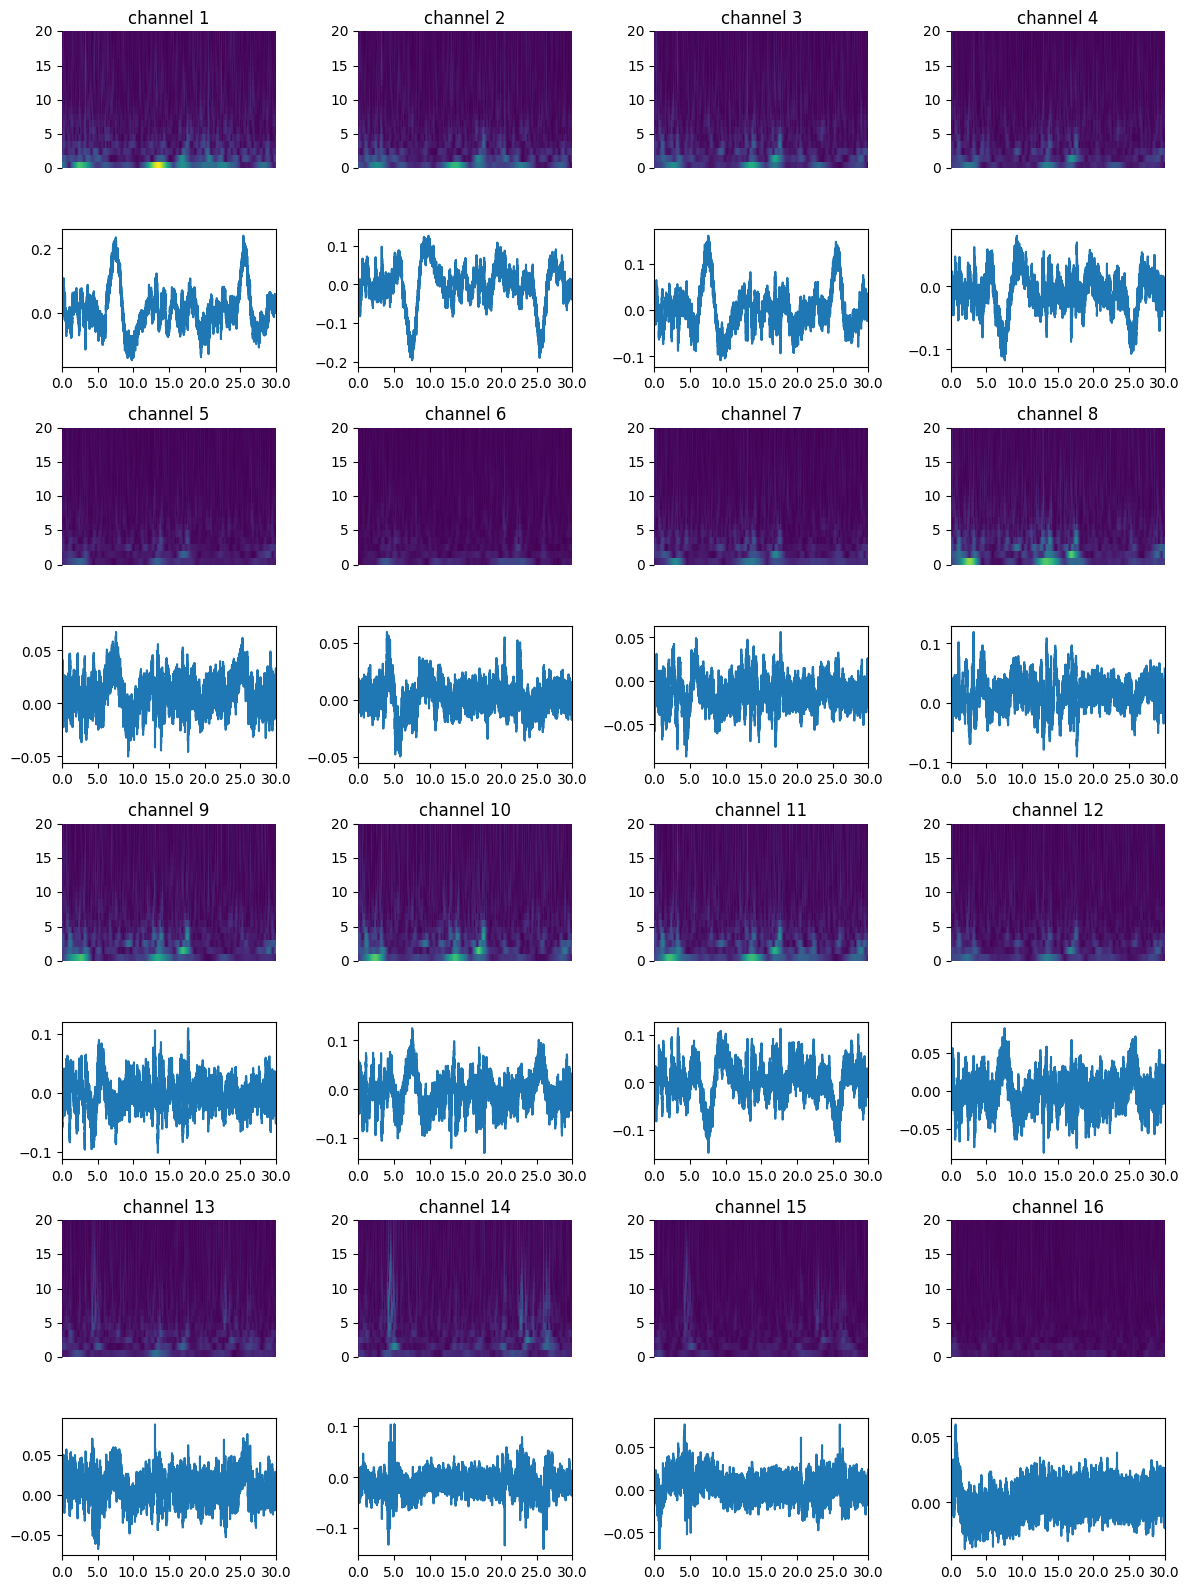

In [ ]:
plt.figure(figsize=(12, 16))
t_max = fs * 30
t_label = 5
vmin, vmax = 0, np.max(cwtmatr[:, :, :t_max])

for channel in range(len(lfp_denoised.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 60)
    plt.yticks(np.arange(0, 61, 10), np.arange(0, 61, 10))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp_denoised[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()

# 0~20 Hz
plt.figure(figsize=(12, 16))
t_max = 30000
t_label = 5

for channel in range(len(lfp_denoised.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 20)
    plt.yticks(np.arange(0, 21, 5), np.arange(0, 21, 5))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp_denoised[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()

In [ ]:
# delta : 1~3.99
# theta : 4~7.99
# alpha : 8~13.99
# beta : 14~60.00

# Phased lock analysis